# Exploratory data analysis: DLPFC spatial transcriptomics

This notebook inspects a single DLPFC 10x Visium section (`151507`) to understand the
structure of the data before any clustering is attempted. All figures share one consistent
colour palette for the cortical layers and a common spatial-plot helper, so the tissue, the
expression space, and the quality metrics can be read against each other directly.

**What we look at:**

1. **Dataset overview:** size, layer composition, and the physical tissue layout of the annotated layers.
2. **Quality control:** transcriptional complexity (genes detected per spot) across tissue and layers.
3. **Expression structure:** the ground-truth layers in PCA and UMAP space, and the PCA variance spectrum.
4. **Separability:** an overall and per-layer silhouette analysis in PCA space.
5. **Spatial coherence:** how consistently each spot's label matches its neighbours, and where the
   boundaries lie.
6. **PC distributions:** marginal shapes and cross-correlations of the leading principal components.

**The recurring message:** the layers overlap heavily in expression space yet are spatially contiguous,
which is exactly why spatially aware encoders outperform expression-only clustering.


In [22]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from pathlib import Path

random.seed(42)

# Where every figure in this notebook is saved.
FIG_DIR = Path("figures/data_analysis")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="white", font_scale=1.05)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "image.cmap": "viridis",
})

In [10]:
import scanpy as sc

adata = sc.read_h5ad("data/DLPFC_151507_ST_final.h5ad")

print(adata)
print(adata.obs.columns)
print(adata.obsm.keys())

AnnData object with n_obs × n_vars = 4221 × 3010
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes', 'image_cluster', 'dbscan_cluster_new'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts'
    uns: 'image_cluster_colors', 'log1p', 'spatial'
    obsm: 'X_pca', 'features', 'features_summary_scale0.5_0.5', 'features_summary_scale0.5_1', 'features_summary_scale0.5_2', 'features_summary_scale1_0.5', 'features_summary_scale1_1', 'features_summary_scale1_2', 'features_summary_scale2_0.5', 'features_summary_scale2_1', 'features_summary_scale2_2', 'spatial'
    obsp: 'adj_f', 'adj_i', 'adj_t'
Index(['in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes',
       'image_cluster', 'dbscan_cluster_new'],
      dtype='object')
KeysView(AxisArrays with keys: X_pca, features, features_summary_scale0.5_0.5, features_summary_scale0.5_1, features_summary_scale0.5_2, features_summary_scale1_0.5, features_summary_scale1_1, features_summary_scale1_2, feat

## Dataset overview

 The basic dimensions of the section are
summarised below.


In [11]:
# Clean, ordered layer annotation shared by every figure below.
gt = adata.obs["Ground Truth"].astype("category")
layer_order = sorted(gt.cat.categories.tolist(), key=str)
adata.obs["Ground Truth"] = gt.cat.reorder_categories(layer_order)

LAYER_PALETTE = dict(zip(layer_order, sns.color_palette("Spectral", len(layer_order))))

coords = np.asarray(adata.obsm["spatial"])


def spatial_scatter(ax, values, title, *, categorical=False, cmap="viridis",
                    s=14, palette=None, colorbar=True):
    """Plot per-spot `values` at their tissue coordinates with a consistent style."""
    if categorical:
        series = pd.Series(np.asarray(values), index=adata.obs_names).astype("category")
        for cat in series.cat.categories:
            mask = (series == cat).to_numpy()
            ax.scatter(coords[mask, 0], coords[mask, 1], s=s, linewidths=0,
                       color=(palette or {}).get(cat, "lightgrey"), label=str(cat))
    else:
        scat = ax.scatter(coords[:, 0], coords[:, 1], c=values, s=s, cmap=cmap, linewidths=0)
        if colorbar:
            plt.colorbar(scat, ax=ax, fraction=0.046, pad=0.04)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title(title)


print(f"Spots (observations): {adata.n_obs:,}")
print(f"Genes (features):     {adata.n_vars:,}")
print(f"Annotated layers:     {len(layer_order)}  ->  {layer_order}")
print(f"Unlabeled spots:      {adata.obs['Ground Truth'].isna().sum()}")

Spots (observations): 4,221
Genes (features):     3,010
Annotated layers:     7  ->  ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'Layer6', 'WM']
Unlabeled spots:      0


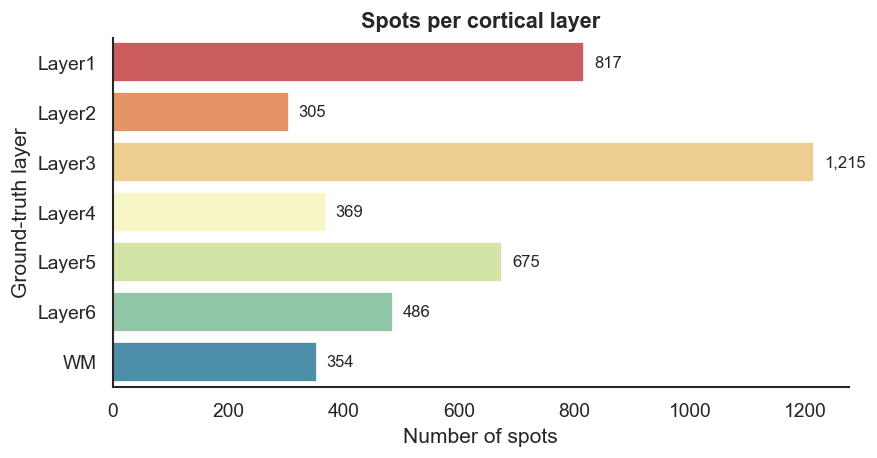

In [23]:
# How many spots belong to each cortical layer?
counts = adata.obs["Ground Truth"].value_counts().reindex(layer_order)

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.barplot(x=counts.values, y=counts.index, hue=counts.index,
            palette=LAYER_PALETTE, legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(v + adata.n_obs * 0.004, i, f"{v:,}", va="center", fontsize=10)
ax.set_xlabel("Number of spots")
ax.set_ylabel("Ground-truth layer")
ax.set_title("Spots per cortical layer")
sns.despine()
plt.tight_layout()
fig.savefig(FIG_DIR / "layer_composition.png", bbox_inches="tight")
plt.show()

## Spatial tissue layout

The annotated layers at their physical positions on the slide. The clean, stacked bands confirm the
cortical layering that expression-only clustering tends to break up.


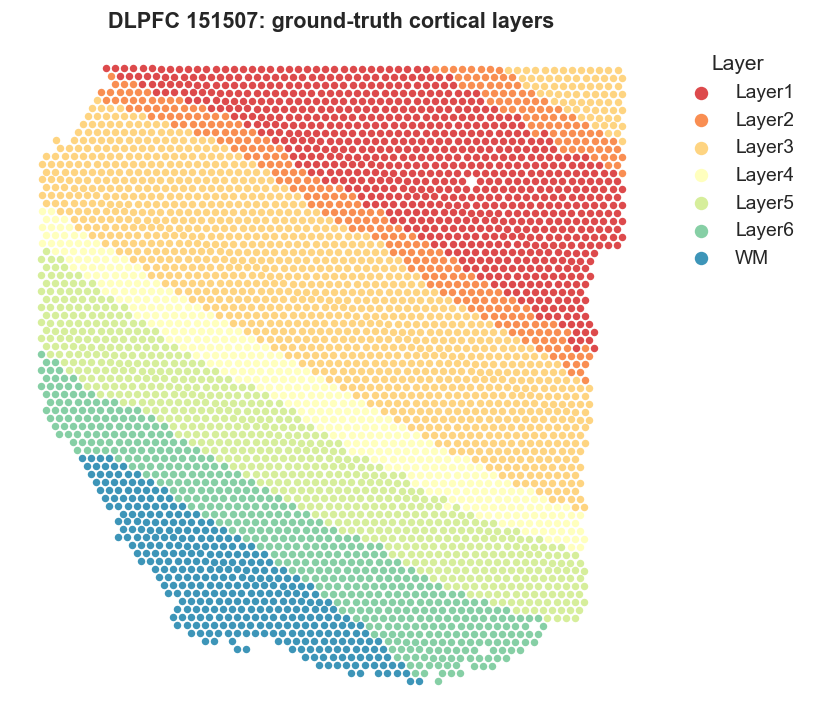

In [24]:
fig, ax = plt.subplots(figsize=(6.8, 6.8))
spatial_scatter(ax, adata.obs["Ground Truth"], "DLPFC 151507: ground-truth cortical layers",
                categorical=True, palette=LAYER_PALETTE, s=20)
ax.legend(title="Layer", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.8)
plt.tight_layout()
fig.savefig(FIG_DIR / "spatial_layers.png", bbox_inches="tight")
plt.show()

## Quality control metrics

`n_genes` (the number of genes detected per spot) is a standard spatial QC measure. Mapping it across the
tissue and comparing it per layer shows that transcriptional complexity itself varies by cortical layer,
notably in white matter.


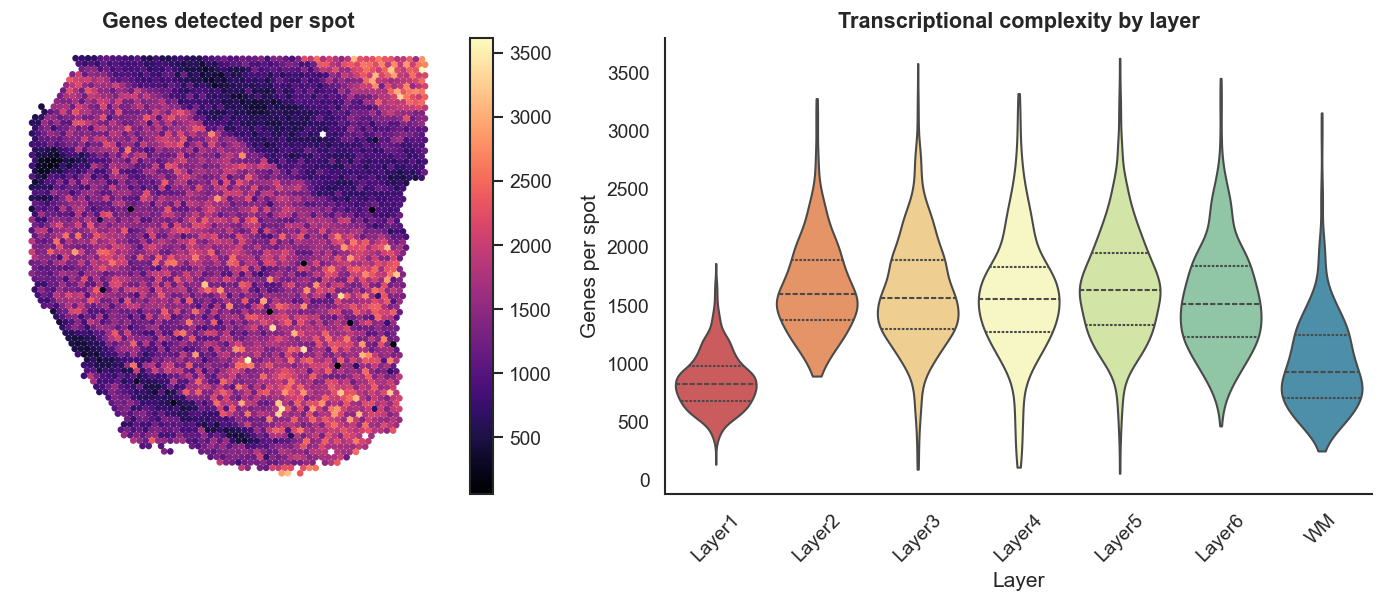

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1, 1.1]})

spatial_scatter(axes[0], adata.obs["n_genes"], "Genes detected per spot", cmap="magma", s=16)

sns.violinplot(data=adata.obs, x="Ground Truth", y="n_genes", order=layer_order,
               hue="Ground Truth", palette=LAYER_PALETTE, legend=False,
               inner="quartile", cut=0, ax=axes[1])
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Genes per spot")
axes[1].set_title("Transcriptional complexity by layer")
axes[1].tick_params(axis="x", rotation=45)
sns.despine(ax=axes[1])
plt.tight_layout()
fig.savefig(FIG_DIR / "qc_genes_per_spot.png", bbox_inches="tight")
plt.show()

## Marker-gene expression

Spatial expression of canonical DLPFC layer-marker genes. Each gene peaks in the cortical layer it marks
(MOBP in white matter, PCP4 in L5, SNAP25 broadly neuronal, HPCAL1 in L2, FABP7 in L1 and astrocytes,
CARTPT around L3-L4), confirming that the annotated layers correspond to real, spatially organised
transcriptional programs.


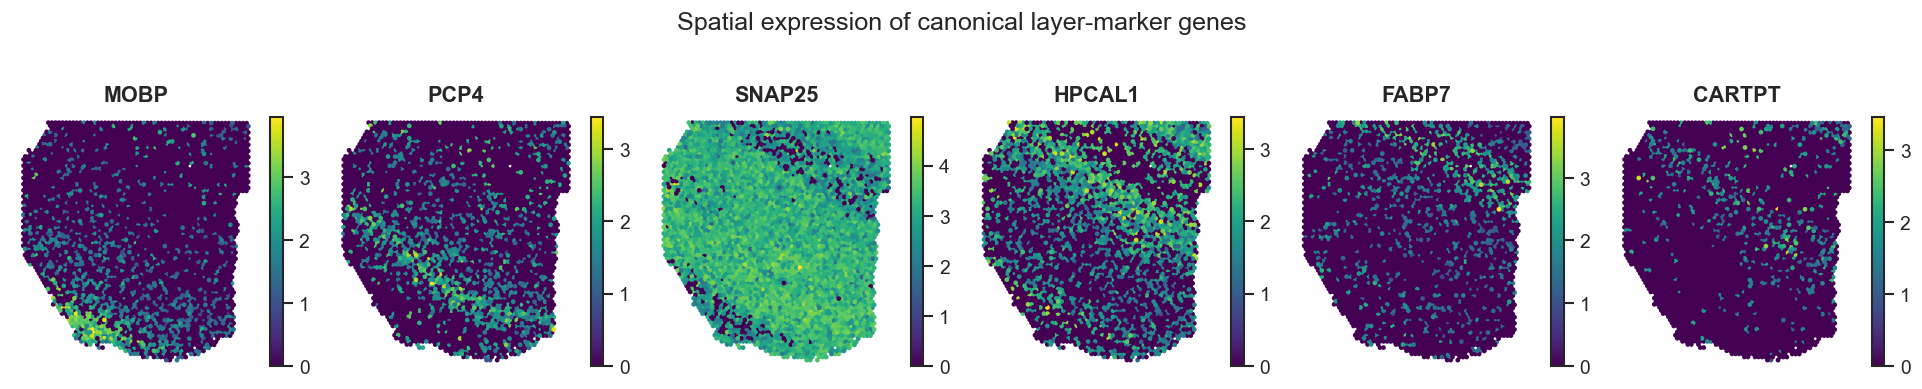

In [26]:
# Canonical DLPFC layer markers and the layer each one marks.
MARKER_GENES = ["MOBP", "PCP4", "SNAP25", "HPCAL1", "FABP7", "CARTPT"]
genes = [g for g in MARKER_GENES if g in set(adata.var_names)]

fig, axes = plt.subplots(1, len(genes), figsize=(2.7 * len(genes), 3.2))
for ax, g in zip(np.atleast_1d(axes).ravel(), genes):
    expr = adata[:, g].X
    expr = expr.toarray().ravel() if hasattr(expr, "toarray") else np.asarray(expr).ravel()
    spatial_scatter(ax, expr, g, cmap="viridis", s=8)

fig.suptitle("Spatial expression of canonical layer-marker genes", y=1.04)
plt.tight_layout()
fig.savefig(FIG_DIR / "marker_genes.png", bbox_inches="tight")
plt.show()

## Ground-truth layers in PCA space

The leading principal components coloured by the manually annotated cortical layer. If the layers formed
compact, well-separated blobs here, expression-only clustering would be easy; the heavy overlap across both
PC1/PC2 and PC3/PC4 is the core difficulty of the task.


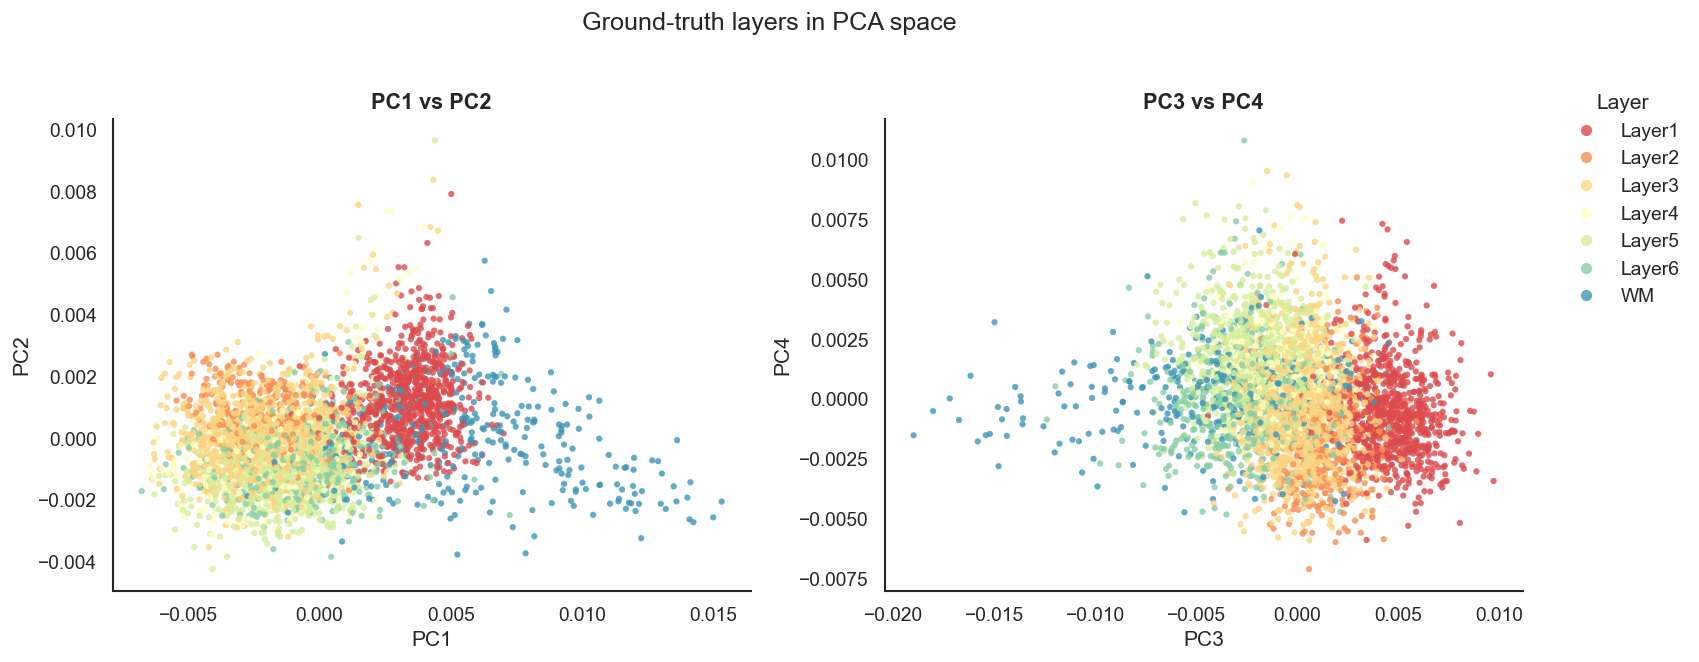

In [27]:
X_pca = np.asarray(adata.obsm["X_pca"])
gt = adata.obs["Ground Truth"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, (a, b) in zip(axes, [(0, 1), (2, 3)]):
    sns.scatterplot(x=X_pca[:, a], y=X_pca[:, b], hue=gt, hue_order=layer_order,
                    palette=LAYER_PALETTE, s=14, linewidth=0, alpha=0.8, ax=ax)
    ax.set_xlabel(f"PC{a + 1}")
    ax.set_ylabel(f"PC{b + 1}")
    ax.set_title(f"PC{a + 1} vs PC{b + 1}")
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Layer", bbox_to_anchor=(1.0, 0.92),
           loc="upper left", markerscale=1.8)
fig.suptitle("Ground-truth layers in PCA space", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "pca_scatter.png", bbox_inches="tight")
plt.show()

### Variance spectrum (scree plot)

PCA recomputed on the log-normalised expression gives a standard, variance-ordered spectrum (the stored
`X_pca` columns are not sorted by variance). The first few components carry most of the signal, and the
cumulative curve shows how many are needed to retain a given fraction, which frames how much an aggressive
low-dimensional projection discards.


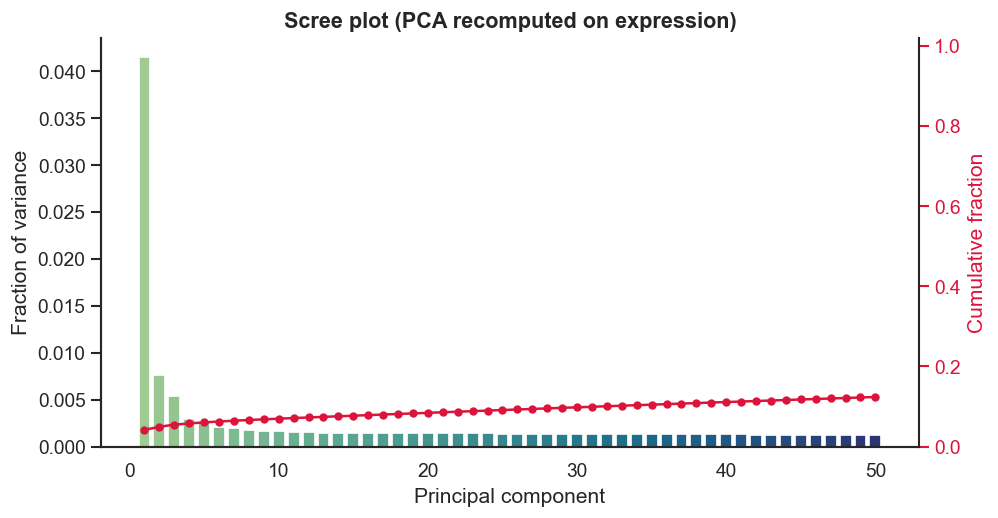

First 2 PCs capture 4.9% of the total variance.
First 5 PCs capture 6.0%.


In [28]:
from sklearn.decomposition import PCA

# Standard, variance-ordered PCA recomputed on the log-normalised expression.
X_expr = adata.X
X_expr = X_expr.toarray() if hasattr(X_expr, "toarray") else np.asarray(X_expr)

ratio = PCA(n_components=50, random_state=0).fit(X_expr).explained_variance_ratio_
cum = np.cumsum(ratio)
k = len(ratio)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(np.arange(1, k + 1), ratio, color=sns.color_palette("crest", k))
ax.set_xlabel("Principal component")
ax.set_ylabel("Fraction of variance")
ax.set_title("Scree plot (PCA recomputed on expression)")

ax2 = ax.twinx()
ax2.plot(np.arange(1, k + 1), cum, color="crimson", marker="o", ms=4)
ax2.set_ylabel("Cumulative fraction", color="crimson")
ax2.tick_params(axis="y", colors="crimson")
ax2.spines["right"].set_visible(True)
ax2.set_ylim(0, 1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "scree.png", bbox_inches="tight")
plt.show()

print(f"First 2 PCs capture {cum[1]:.1%} of the total variance.")
print(f"First 5 PCs capture {cum[4]:.1%}.")

### Non-linear embedding (UMAP)

A UMAP of the PCA representation gives a cleaner 2D view of the layer structure than raw PC pairs. Even
here the layers form a gradient with substantial overlap rather than cleanly separated islands.


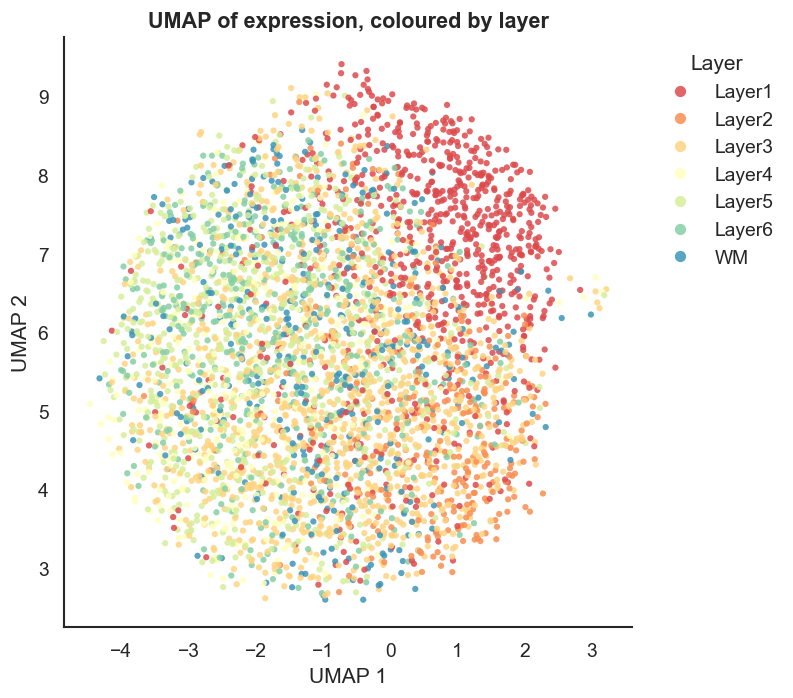

In [29]:
# Build a neighbour graph on the PCA space and embed it with UMAP.
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15, random_state=0)
sc.tl.umap(adata, random_state=0)

umap = np.asarray(adata.obsm["X_umap"])
fig, ax = plt.subplots(figsize=(6.8, 6))
sns.scatterplot(x=umap[:, 0], y=umap[:, 1], hue=adata.obs["Ground Truth"],
                hue_order=layer_order, palette=LAYER_PALETTE, s=14,
                linewidth=0, alpha=0.85, ax=ax)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of expression, coloured by layer")
ax.legend(title="Layer", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.8)
plt.tight_layout()
fig.savefig(FIG_DIR / "umap.png", bbox_inches="tight")
plt.show()

## Cluster separability (silhouette analysis)

The overall silhouette score summarises how well the ground-truth labels are separated in the first 10 PCs.
The per-layer silhouette diagram breaks that down: wide bands reaching positive values are well-separated
layers, while thin or negative bands are layers that blend into their neighbours in expression space.


Overall silhouette score (10 PCs): 0.063


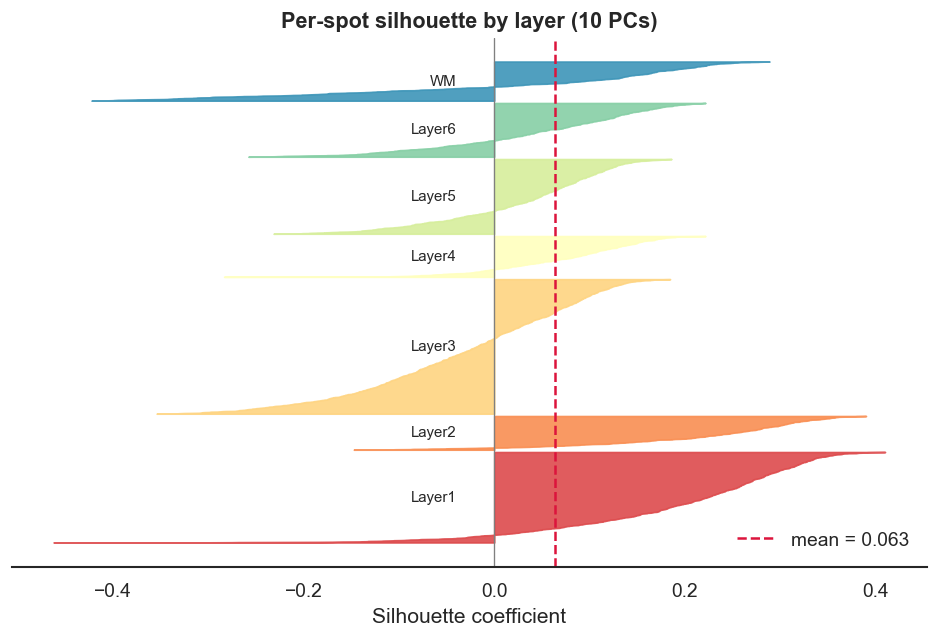

In [30]:
from sklearn.metrics import silhouette_score, silhouette_samples

X = np.asarray(adata.obsm["X_pca"])[:, :10]
codes = adata.obs["Ground Truth"].cat.codes.to_numpy()
valid = codes >= 0  # drop any unlabeled spots
X, codes = X[valid], codes[valid]

overall = silhouette_score(X, codes)
sample_sil = silhouette_samples(X, codes)
print(f"Overall silhouette score (10 PCs): {overall:.3f}")

fig, ax = plt.subplots(figsize=(8, 5.5))
y_lower = 0
for i, layer in enumerate(layer_order):
    mask = codes == i
    if not mask.any():
        continue
    vals = np.sort(sample_sil[mask])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     color=LAYER_PALETTE[layer], alpha=0.9)
    ax.text(-0.04, y_lower + len(vals) / 2, str(layer), va="center", ha="right", fontsize=9)
    y_lower = y_upper + 20

ax.axvline(overall, color="crimson", ls="--", lw=1.5, label=f"mean = {overall:.3f}")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([])
ax.set_title("Per-spot silhouette by layer (10 PCs)")
ax.legend(loc="lower right")
sns.despine(left=True)
plt.tight_layout()
fig.savefig(FIG_DIR / "silhouette.png", bbox_inches="tight")
plt.show()

## Spatial coherence of the labels

For each spot, the fraction of its 6 nearest spatial neighbours that share its layer label. The histogram
shows most spots sit deep inside a homogeneous region, and the spatial map reveals that the few
low-agreement spots line up along the layer boundaries. This spatial smoothness is the signal that
spatially aware encoders exploit and that expression-only methods ignore.


Mean neighbour label agreement: 0.923


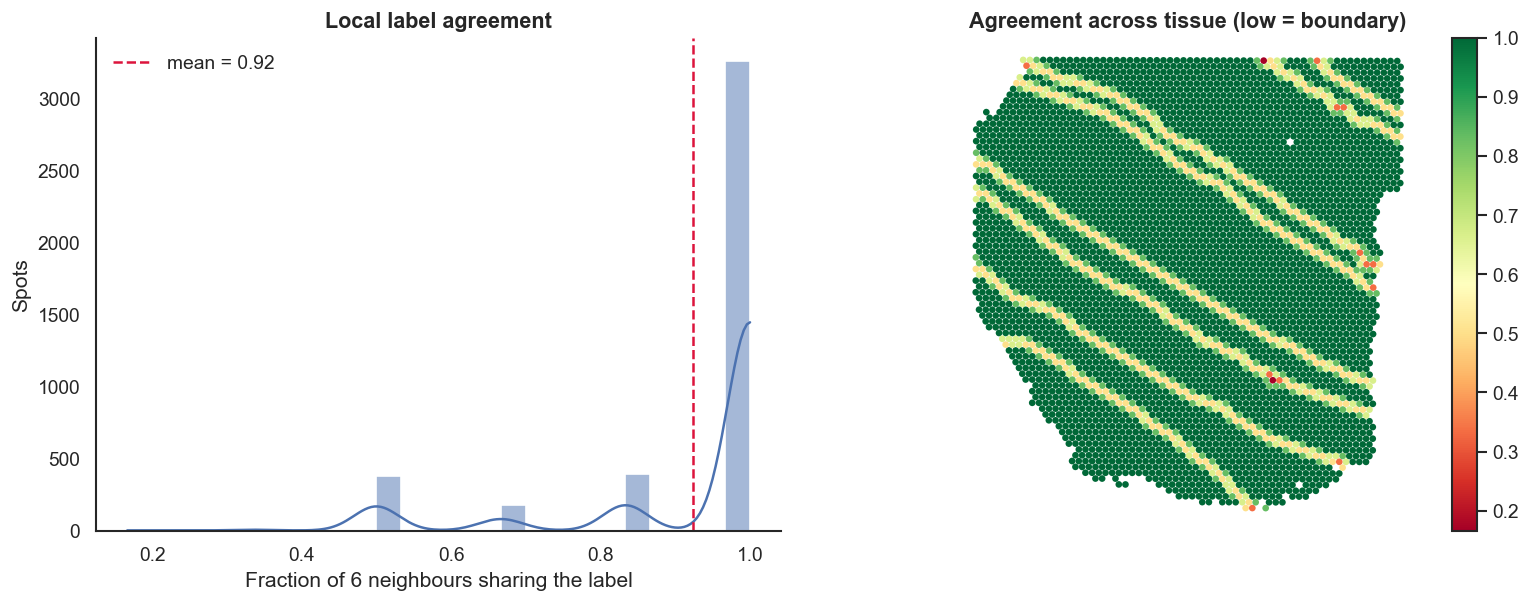

In [31]:
from sklearn.neighbors import NearestNeighbors

codes = adata.obs["Ground Truth"].cat.codes.to_numpy()
nbrs = NearestNeighbors(n_neighbors=7).fit(coords)  # 6 neighbours + self
_, idx = nbrs.kneighbors(coords)
idx = idx[:, 1:]  # drop the self match

agreement = (codes[idx] == codes[:, None]).mean(axis=1)
adata.obs["neighbor_agreement"] = agreement
print(f"Mean neighbour label agreement: {agreement.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1, 1.1]})

sns.histplot(agreement, bins=25, kde=True, color="#4C72B0", ax=axes[0])
axes[0].axvline(agreement.mean(), color="crimson", ls="--",
                label=f"mean = {agreement.mean():.2f}")
axes[0].set_xlabel("Fraction of 6 neighbours sharing the label")
axes[0].set_ylabel("Spots")
axes[0].set_title("Local label agreement")
axes[0].legend()
sns.despine(ax=axes[0])

spatial_scatter(axes[1], agreement, "Agreement across tissue (low = boundary)",
                cmap="RdYlGn", s=16)
plt.tight_layout()
fig.savefig(FIG_DIR / "spatial_coherence.png", bbox_inches="tight")
plt.show()

## Distribution of the leading principal components

Most of the leading PCs look roughly bell-shaped, though PC1 is clearly bimodal, reflecting the strong
white-matter versus cortex split. The correlation heatmap shows the components are only weakly correlated.
As the closing note explains, the *joint* distribution is still a mixture of overlapping, anisotropic
clusters, which breaks the clean Gaussian-mixture assumption even when each margin looks well behaved.


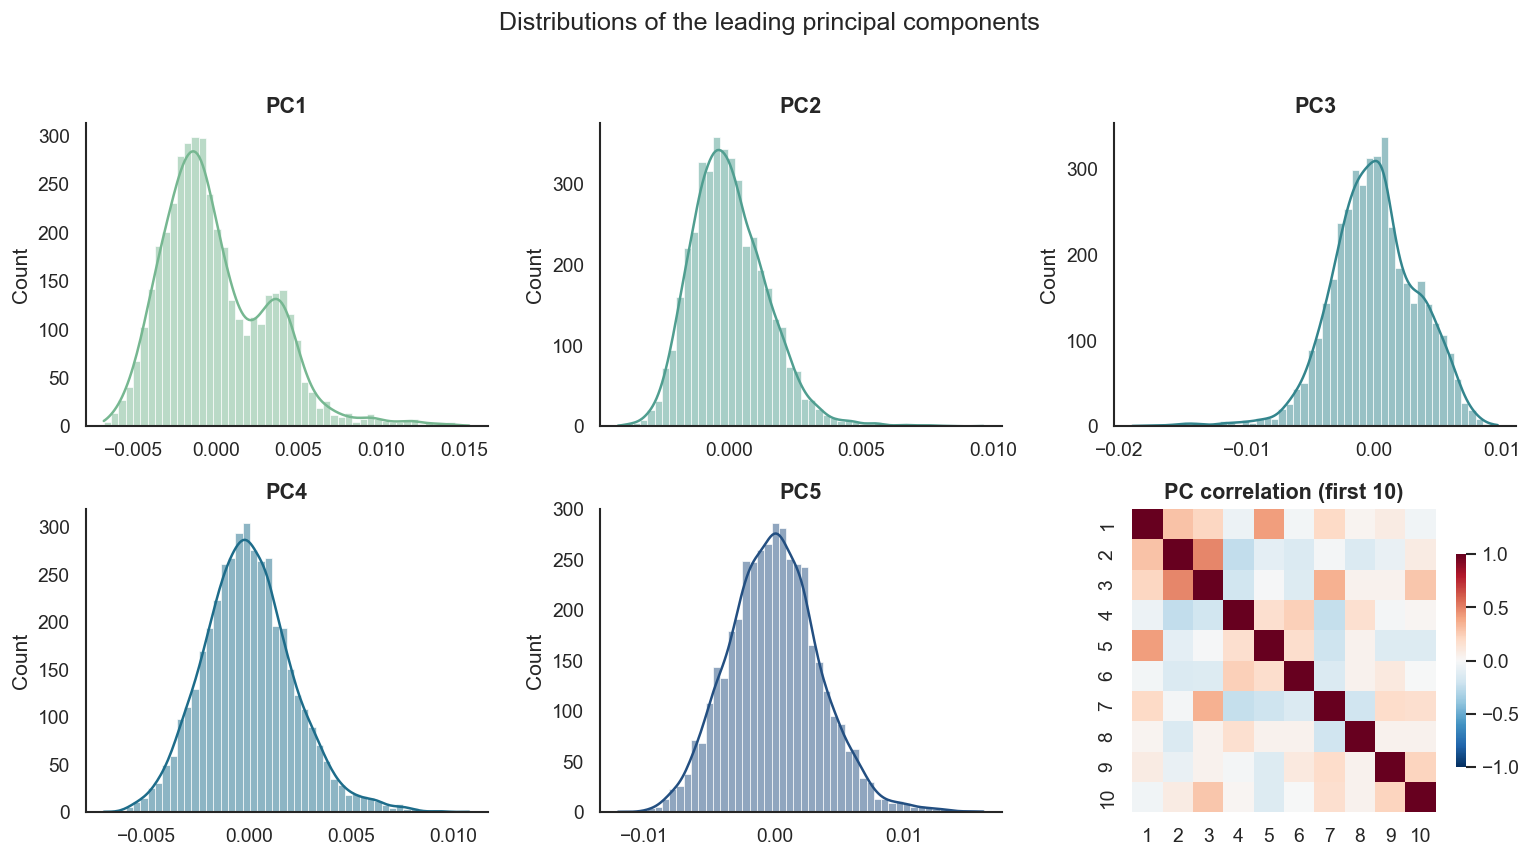

In [32]:
X_pca = np.asarray(adata.obsm["X_pca"])
pc_colors = sns.color_palette("crest", 5)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
flat = axes.ravel()
for i in range(5):
    sns.histplot(X_pca[:, i], bins=50, kde=True, color=pc_colors[i], ax=flat[i])
    flat[i].set_title(f"PC{i + 1}")
    flat[i].set_xlabel("")
    sns.despine(ax=flat[i])

# Final panel: correlation among the first 10 PCs.
corr = np.corrcoef(X_pca[:, :10].T)
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, xticklabels=range(1, 11),
            yticklabels=range(1, 11), ax=flat[5])
flat[5].set_title("PC correlation (first 10)")

fig.suptitle("Distributions of the leading principal components", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "pc_distributions.png", bbox_inches="tight")
plt.show()

## Cross-section comparison

The detailed figures above use one section (151507) as a worked example. This panel summarises all 12 DLPFC
sections to confirm it is representative, and surfaces an important structural difference: the middle
donor's sections (151669-151672) carry only 5 annotated domains (L1/L2 are absent), while the other eight
have 7. Across every section the expression-space separability (silhouette) stays low and the spatial
neighbour agreement stays high, exactly as seen for 151507.


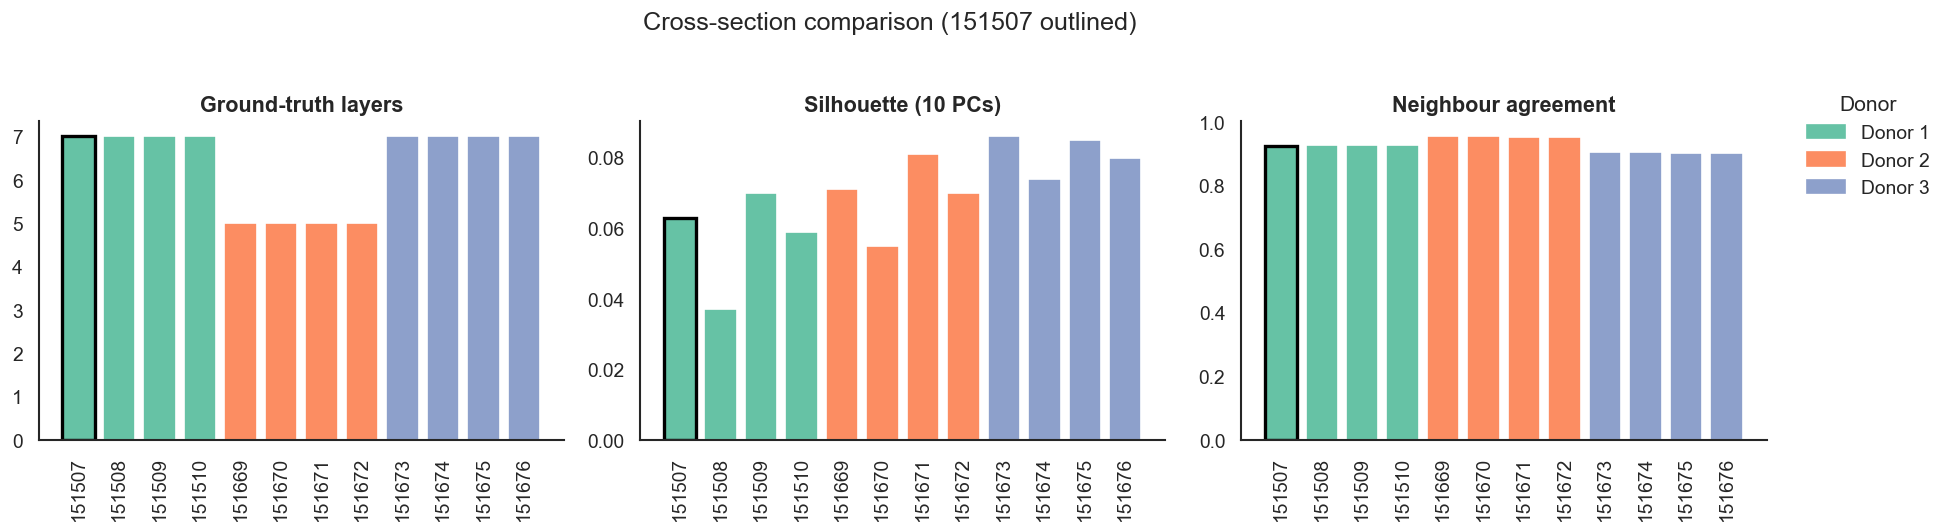

,section,donor,n_spots,median_genes,n_layers,silhouette,neighbor_agreement
0,151507,Donor 1,4221,1384,7,0.063,0.923
1,151508,Donor 1,4380,1159,7,0.037,0.927
2,151509,Donor 1,4787,1407,7,0.070,0.927
3,151510,Donor 1,4593,1346,7,0.059,0.926
4,151669,Donor 2,3636,1730,5,0.071,0.954
5,151670,Donor 2,3484,1607,5,0.055,0.954
6,151671,Donor 2,4093,1856,5,0.081,0.953
7,151672,Donor 2,3888,1766,5,0.070,0.951
8,151673,Donor 3,3611,2117,7,0.086,0.905
9,151674,Donor 3,3635,2609,7,0.074,0.904


In [33]:
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

SECTIONS = [
    "151507", "151508", "151509", "151510",   # donor 1
    "151669", "151670", "151671", "151672",   # donor 2
    "151673", "151674", "151675", "151676",   # donor 3
]
DONOR = {s: f"Donor {d + 1}"
         for d, grp in enumerate([SECTIONS[:4], SECTIONS[4:8], SECTIONS[8:]]) for s in grp}

rows = []
for sec in SECTIONS:
    ad = sc.read_h5ad(f"data/DLPFC_{sec}_ST_final.h5ad")
    labels = ad.obs["Ground Truth"].astype("category")
    codes = labels.cat.codes.to_numpy()
    valid = codes >= 0

    Xp = np.asarray(ad.obsm["X_pca"])[:, :10][valid]
    sil = silhouette_score(Xp, codes[valid]) if np.unique(codes[valid]).size > 1 else np.nan

    xy = np.asarray(ad.obsm["spatial"])
    _, nidx = NearestNeighbors(n_neighbors=7).fit(xy).kneighbors(xy)
    agree = (codes[nidx[:, 1:]] == codes[:, None]).mean(axis=1).mean()

    rows.append({
        "section": sec,
        "donor": DONOR[sec],
        "n_spots": ad.n_obs,
        "median_genes": int(np.median(ad.obs["n_genes"])),
        "n_layers": int(labels.nunique()),
        "silhouette": round(float(sil), 3),
        "neighbor_agreement": round(float(agree), 3),
    })

summary_df = pd.DataFrame(rows)

donor_palette = dict(zip(sorted(summary_df["donor"].unique()), sns.color_palette("Set2", 3)))
bar_colors = summary_df["donor"].map(donor_palette).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
metrics = [("n_layers", "Ground-truth layers"),
           ("silhouette", "Silhouette (10 PCs)"),
           ("neighbor_agreement", "Neighbour agreement")]
for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(summary_df["section"], summary_df[col], color=bar_colors)
    for bar, sec in zip(bars, summary_df["section"]):
        if sec == "151507":                       # outline the worked example
            bar.set_edgecolor("black")
            bar.set_linewidth(2)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=90)
    sns.despine(ax=ax)

handles = [mpl.patches.Patch(color=c, label=d) for d, c in donor_palette.items()]
fig.legend(handles=handles, title="Donor", bbox_to_anchor=(1.0, 0.9), loc="upper left")
fig.suptitle("Cross-section comparison (151507 outlined)", y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / "cross_section_summary.png", bbox_inches="tight")
plt.show()

summary_df

## Takeaways

- **Spatially, the layers are clean:** the tissue map shows well-defined cortical bands and neighbour
  agreement is high, with disagreement concentrated at the boundaries.
- **In expression space, they are not:** PCA and UMAP show heavy overlap, the silhouette score is low, and
  the leading PCs capture only a modest share of the variance.
- **Why it matters:** while individual components may look approximately Gaussian in isolation, the overall
  data consists of overlapping and anisotropic clusters, which violate standard Gaussian-mixture
  assumptions. Methods that use spatial position (not expression alone) are therefore expected to recover
  the layers far better, which is exactly what the rest of the project investigates.
